# Site Setup

Define your site once, interactively, and save a reusable JSON config that every other historical air-temperature notebook will load.

You will:

1. Enter your **site name** and **longitude / latitude**.
2. Enter your **country** — the notebook looks it up in the GHCN country list and suggests matches if the exact name is not found.
3. The notebook downloads the GHCN-Daily station list, filters by your country and ranks stations by distance to your site so you can pick the closest one.
4. Pick the **station ID**.
5. Choose **variables of interest**, **reference period** and **completeness threshold**.
6. Save everything to `data/sites/<site>.json`.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

sys.path.append("../../functions")
from air_temp import haversine_km, save_site_config
from data_downloaders import GHCN, filter_by_time_completeness

## 1. Site name and coordinates

Edit the values below with your own site. Longitudes are in decimal degrees in the range `(-180, 180]`; latitudes in `(-90, 90)`. The country name does not need to match GHCN's spelling exactly — the next step will help you find the right one.

In [2]:
site_name = "Palau" #can be any name
site_lon = 134.620
site_lat = 7.340
country = "Palau"

print(f"Site: {site_name}  ({site_lat:+.3f} N, {site_lon:+.3f} E)")
print(f"Country (as typed): {country!r}")

Site: Palau  (+7.340 N, +134.620 E)
Country (as typed): 'Palau'


## 2. Find the GHCN country code

GHCN-Daily identifies stations with a two-letter country prefix. We look up your `country` in the official country list:

- if there is an **exact** match, we use it directly,
- otherwise we show all entries whose name **contains** what you typed so you can pick the right spelling.

Re-run this cell after editing `country` above until you get a single match.

In [3]:
df_countries = GHCN.download_country_codes()

exact = GHCN.get_country_code(country)

if len(exact) == 1:
    country_code = exact["Code"].iloc[0]
    country_name = exact["Country"].iloc[0]
    print(f"Exact match: {country_name!r} -> code {country_code!r}")
else:
    suggestions = df_countries[
        df_countries["Country"].str.contains(country, case=False, na=False)
    ]
    if len(suggestions) == 0:
        print(
            f"No country matches {country!r}. Showing the full list so you can "
            "pick one; copy it back into the `country` variable above and re-run."
        )
        display(df_countries)
    else:
        print(
            f"{len(suggestions)} possible matches for {country!r}. "
            "Copy the exact name into `country` above and re-run this step."
        )
        display(suggestions)
    country_code = None
    country_name = None

Exact match: 'Palau' -> code 'PS'


## 3. Find the closest GHCN stations

We download the full GHCN-Daily station inventory, keep only the stations whose ID starts with your country code, compute the great-circle distance to your `(site_lon, site_lat)` and show the 15 closest ones.

If your country code is `None` (Step 2 did not converge), go back and pick a country name first.

In [4]:
assert country_code is not None, "Resolve the country code in Step 2 before running this cell."

df_stations = GHCN.download_stations_info()
df_country_stations = df_stations[df_stations["ID"].str.startswith(country_code)].copy()

print(f"{len(df_country_stations)} GHCN stations registered under country code {country_code!r}.")

df_country_stations["distance_km"] = haversine_km(
    site_lon, site_lat,
    df_country_stations["Longitude"].values,
    df_country_stations["Latitude"].values,
)

nearest = df_country_stations.sort_values("distance_km").head(15).reset_index(drop=True)
nearest[["ID", "Name", "Latitude", "Longitude", "Elevation", "distance_km"]]

13 GHCN stations registered under country code 'PS'.


,ID,Name,Latitude,Longitude,Elevation,distance_km
0,PSC00914904,PW WSO PALAU,7.3689,134.5411,27.4,9.275560
1,PSC00914913,PW WSO PALAU AIRAI,7.3689,134.5411,27.4,9.275560
2,PSW00040307,PW KOROR ISLAND NF,7.3333,134.4833,30.2,15.094297
3,PSW00040309,PW KOROR GSN 91408,7.3367,134.4769,27.4,15.785927
4,PSC00914015,PW AIMELIK BABELTHUAP,7.4500,134.5167,60.0,16.714085
5,PSC00914519,PW NEKKEN FORESTRY,7.4500,134.5000,31.1,18.019564
6,PSC00914465,PW MALAKAL RSCH,7.3333,134.4500,75.9,18.763173
7,PSC00914478,PW MARICULTURE CTR,7.3333,134.4500,3.0,18.763173
8,PSC00914580,PW NGASANG BABELTHUAP,7.6333,134.6500,3.0,32.780749
9,PSC00914712,PW PELELIU,7.0333,134.2667,3.0,51.790098


## 4. Pick a station

By default we use the **closest** station from the table above. To override, set `ghcn_station_id` to one of the `ID` values shown (the station name is filled in automatically).

In [ ]:
i = 3 #3 #0 is the closest station
# Palau: PW KOROR GSN 91408
# Majuro: MH MAJURO WBAS AP GSN 91376
# Kwajalein: MH KWAJALEIN GSN 91366

ghcn_station_id = nearest.loc[i, "ID"]

station_row = df_country_stations.loc[df_country_stations["ID"] == ghcn_station_id]
assert len(station_row) == 1, f"Station ID {ghcn_station_id!r} not found for {country_code!r}."

ghcn_station_name = station_row["Name"].iloc[0]
station_distance_km = float(station_row["distance_km"].iloc[0])

print(f"Selected station: {ghcn_station_id} - {ghcn_station_name}")
print(f"  located {station_distance_km:.1f} km from {site_name}")

Selected station: PSW00040309 - PW KOROR GSN 91408
  located 15.8 km from Palau


## 5. Variables and reference period

- `vars_interest`: GHCN variables to download (`"TMIN"`, `"TMAX"`, `"TAVG"`, `"PRCP"`, ...).
- `reference_period_start` / `reference_period_end`: 4-character years used as the climatology baseline (WMO standard: 1961–1990).
- `completeness_threshold`: minimum fraction of valid days/months required to keep a period (default `0.75`).

In [6]:
vars_interest = ["TMIN", "TMAX"]
reference_period_start = "1961"
reference_period_end = "1990"
completeness_threshold = 0.75

print(f"Variables of interest: {vars_interest}")
print(f"Reference period: {reference_period_start}-{reference_period_end}")
print(f"Completeness threshold: {completeness_threshold:.0%}")

Variables of interest: ['TMIN', 'TMAX']
Reference period: 1961-1990
Completeness threshold: 75%


## 6. Save the site configuration

We assemble all the choices made above into a single dictionary and persist it as JSON. The downstream notebooks (`a_mean_temperature`, `b_min_max_temperature`, `c_hot_cold_days`) load this file via `air_temp.load_site_config`.

The filename is derived from the site name (lowercased, non-alphanumerics replaced with `_`).

In [7]:
site_config = {
    "site_name": site_name,
    "site_lon": float(site_lon),
    "site_lat": float(site_lat),
    "country": country_name,
    "ghcn_station_id": ghcn_station_id,
    "ghcn_station_name": ghcn_station_name,
    "vars_interest": list(vars_interest),
    "reference_period_start": str(reference_period_start),
    "reference_period_end": str(reference_period_end),
    "completeness_threshold": float(completeness_threshold),
}

safe_name = "".join(ch.lower() if ch.isalnum() else "_" for ch in site_name).strip("_")
config_out = Path("../../data/sites") / f"{safe_name}.json"

save_site_config(site_config, config_out)
print(f"Saved site config: {config_out.resolve()}")
site_config

Saved site config: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_AirTemp/data/sites/palau.json


{'site_name': 'Palau',
 'site_lon': 134.62,
 'site_lat': 7.34,
 'country': 'Palau',
 'ghcn_station_id': 'PSW00040309',
 'ghcn_station_name': 'PW KOROR GSN 91408',
 'vars_interest': ['TMIN', 'TMAX'],
 'reference_period_start': '1961',
 'reference_period_end': '1990',
 'completeness_threshold': 0.75}

## 7. Download and cache GHCN station data

Once the station is fixed, we download the time series for every variable in `vars_interest` from the GHCN-Daily CSV archive and cache the result on disk so that notebooks `a_`, `b_` and `c_` only need to read the pickle.

The cache file is **per station** (`GHCN_<ghcn_station_id>.pkl`) — switching to a different station regenerates a separate file instead of overwriting the previous one. Set `force_redownload = True` to refresh an existing cache.

In [8]:
force_redownload = False

GHCND_dir = "https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/"
data_dir = Path("../../data/air_temp")
data_dir.mkdir(parents=True, exist_ok=True)
pickle_path = data_dir / f"GHCN_{ghcn_station_id}.pkl"

if pickle_path.exists() and not force_redownload:
    st_data = pd.read_pickle(pickle_path)
    print(f"Loaded cached data: {pickle_path}")
    print("Set force_redownload = True above to refresh.")
else:
    print(f"Downloading {', '.join(vars_interest)} for station {ghcn_station_id}...")
    df_target = df_country_stations.loc[df_country_stations["ID"] == ghcn_station_id]

    frames = []
    for var in vars_interest:
        result, _ = GHCN.extract_dict_data_var(GHCND_dir, var, df_target)
        if not result:
            print(f"  WARNING: variable {var!r} not available for {ghcn_station_id}.")
            continue
        frames.append(result[0]["data"])

    if not frames:
        raise RuntimeError(
            f"None of {vars_interest} are available for station {ghcn_station_id}."
        )

    st_data = pd.concat(frames, axis=1).dropna()

    if {"TMIN", "TMAX"}.issubset(st_data.columns):
        st_data["diff"] = st_data["TMAX"] - st_data["TMIN"]
        st_data["TMEAN"] = (st_data["TMAX"] + st_data["TMIN"]) / 2

    st_data.to_pickle(pickle_path)
    print(f"Saved {len(st_data)} rows to {pickle_path}")

print(f"Date range: {st_data.index.min().date()} to {st_data.index.max().date()}")
st_data.head()

Loaded cached data: ../../data/air_temp/GHCN_PSW00040309.pkl
Set force_redownload = True above to refresh.
Date range: 1951-07-01 to 2026-04-30


,TMIN,TMAX,diff,TMEAN
DATE,,,,
1951-07-01,23.9,32.2,8.3,28.05
1951-07-02,24.4,31.7,7.3,28.05
1951-07-03,23.9,30.6,6.7,27.25
1951-07-04,23.3,28.9,5.6,26.10
1951-07-05,23.9,31.1,7.2,27.50


## 8. Light outlier filter

GHCN occasionally has obviously bad daily values (e.g. a `TMIN` of 500 °C). We drop any row where **any** numeric column lies beyond `threshold_sigma` standard deviations from its column mean. The default of 5σ only catches clearly impossible values, so legitimate extremes are preserved.

The cleaned series overwrites the cached pickle so that downstream notebooks (`a_`, `b_`, `c_`) load the filtered data directly.

In [9]:
threshold_sigma = 5.0

n_before = len(st_data)
numeric_cols = st_data.select_dtypes(include="number").columns

mask = pd.Series(True, index=st_data.index)
print(f"Outlier filter at \u00b1{threshold_sigma}\u03c3 from the column mean:")
for col in numeric_cols:
    mean = st_data[col].mean()
    std = st_data[col].std()
    col_mask = (st_data[col] - mean).abs() <= threshold_sigma * std
    n_out = int((~col_mask).sum())
    if n_out:
        bad = st_data.loc[~col_mask, col]
        print(
            f"  {col}: mean={mean:.2f}, std={std:.2f}, dropping {n_out} value(s) "
            f"in [{bad.min():.2f}, {bad.max():.2f}]"
        )
    mask &= col_mask

st_data = st_data.loc[mask]
removed = n_before - len(st_data)
print(f"\nKept {len(st_data)}/{n_before} rows (removed {removed}, {removed/n_before:.2%}).")

st_data.to_pickle(pickle_path)
print(f"Updated cached pickle: {pickle_path}")

Outlier filter at ±5.0σ from the column mean:

Kept 25966/25966 rows (removed 0, 0.00%).
Updated cached pickle: ../../data/air_temp/GHCN_PSW00040309.pkl


## 9. Time-completeness filter

Drop months that have fewer than `completeness_threshold` of their calendar days observed, then drop years that have fewer than `completeness_threshold` of their months pass. The threshold is the one you set in step 5 (default 0.75).

The cleaned series overwrites the cached pickle, so `a_`, `b_` and `c_` already load completeness-filtered data.

In [10]:
df_filt, removed_months, removed_years = filter_by_time_completeness(
    st_data,
    month_threshold=completeness_threshold,
    year_threshold=completeness_threshold,
)
print(f"Removed {removed_months.shape[0]} months due to insufficient data: {removed_months.index.tolist()}")
print(f"Removed {removed_years.shape[0]} years due to insufficient data: {removed_years.index.tolist()}")

st_data = df_filt
st_data.to_pickle(pickle_path)
print(f"Updated cached pickle: {pickle_path}")

Removed 0 months due to insufficient data: []
Removed 0 years due to insufficient data: []
Updated cached pickle: ../../data/air_temp/GHCN_PSW00040309.pkl


## 10. Quick look at the downloaded data

One subplot per variable in `st_data`, on the same shared time axis. This is a quick QC plot: long gaps, obvious outliers or a too-short record will jump out here before you spend time in the analysis notebooks.

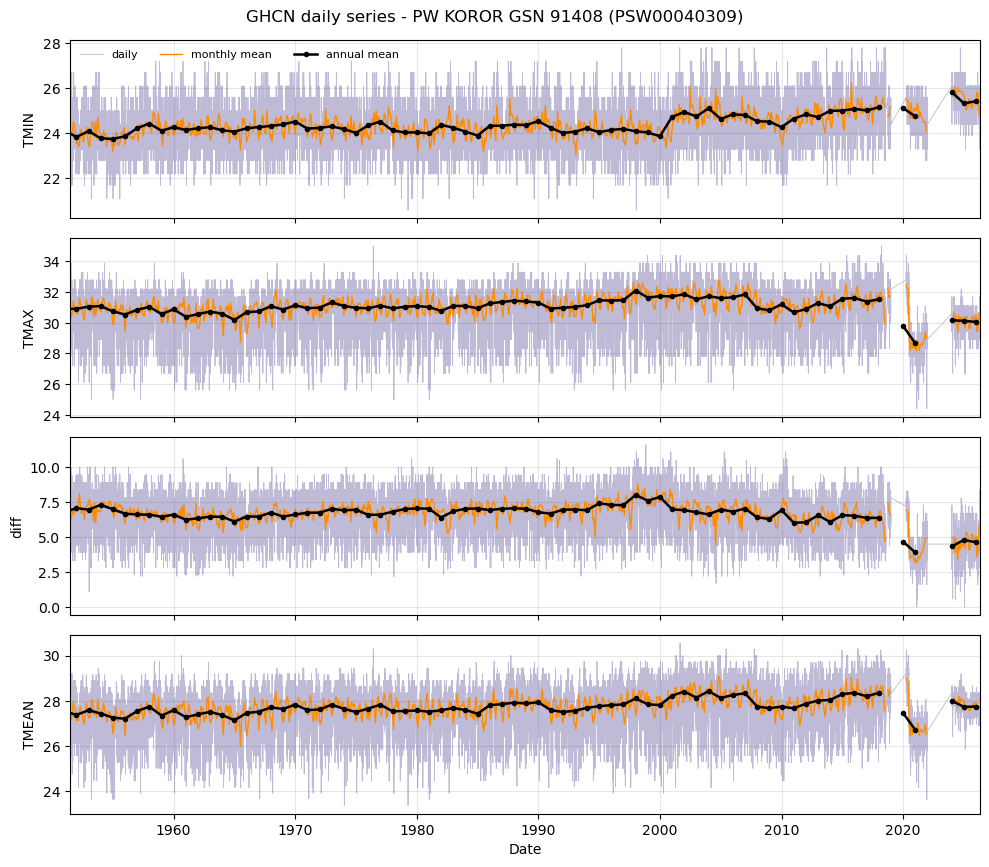

In [11]:
import matplotlib.pyplot as plt

cols = list(st_data.columns)
monthly = st_data[cols].resample("MS").mean()
annual = st_data[cols].resample("YS").mean()

fig, axes = plt.subplots(len(cols), 1, figsize=(10, 2.2 * len(cols)), sharex=True)
if len(cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cols):
    ax.plot(st_data.index, st_data[col], lw=0.6, color="darkslateblue", alpha=0.35, label="daily")
    ax.plot(monthly.index, monthly[col], lw=1.0, color="darkorange", label="monthly mean")
    ax.plot(annual.index, annual[col], lw=1.8, color="black", marker="o", ms=3, label="annual mean")
    ax.set_xlim(st_data.index.min(), st_data.index.max())
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[0].legend(loc="upper left", ncol=3, fontsize=8, frameon=False)
axes[-1].set_xlabel("Date")
fig.suptitle(f"GHCN daily series - {ghcn_station_name} ({ghcn_station_id})")
fig.tight_layout()
plt.show()